In [1]:
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,SubsetRandomSampler,ConcatDataset
import torch.nn.functional as F

import boda

In [2]:
from akita_coda_helper import plot_map, from_upper_triu

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model import SeqNN

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [5]:
# Load the entire model (architecture + weights)
model = torch.load("/home1/smaruj/pytorch_akita/model.pth")

/tmp/SLURM_220597/ipykernel_2144738/3921338739.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("/home1/smaruj/pytorch_akita/model.pth")


In [6]:
model = model.to(device)

In [7]:
# Set the model to evaluation mode (important for inference)
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (re_lu): ReLU()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 96, kernel_size=(11,), stride=(1,), padding=(5,), bias=False)
    (batch_norm): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size

In [8]:
from torchinfo import summary

summary(model, input_size=(2, 4, 1048576), col_names=["output_size", "num_params"])

Layer (type:depth-idx)                   Output Shape              Param #
SeqNN                                    [2, 5, 99681]             --
├─StochasticReverseComplement: 1-1       [2, 4, 1048576]           --
├─StochasticShift: 1-2                   [2, 4, 1048576]           --
├─ReLU: 1-3                              [2, 4, 1048576]           --
├─ConvBlock: 1-4                         [2, 96, 524288]           --
│    └─Conv1d: 2-1                       [2, 96, 1048576]          4,224
│    └─BatchNorm1d: 2-2                  [2, 96, 1048576]          192
│    └─MaxPool1d: 2-3                    [2, 96, 524288]           --
├─ConvTower: 1-5                         [2, 96, 512]              --
│    └─Sequential: 2-4                   [2, 96, 512]              --
│    │    └─ReLU: 3-1                    [2, 96, 524288]           --
│    │    └─Conv1d: 3-2                  [2, 96, 524288]           46,080
│    │    └─BatchNorm1d: 3-3             [2, 96, 524288]           192
│    │

In [9]:
from pyfaidx import Fasta

In [10]:
fasta_file = "/project/fudenber_735/genomes/hg38/hg38.fa"
genome = Fasta(fasta_file)

# region = "chr12"
# start = 115163136
# end = 116211712

region = "chr11"
start = 75429888
end = 76478464

# region = "chr15"
# start = 63281152
# end = 64329728

In [11]:
sequence = genome[region][start:end]

In [12]:
genome.close()

In [13]:
import numpy as np

In [14]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()

    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

    # Step 1: Encode the sequence to integers
    encoded_sequence = np.array([base_to_int[base] for base in sequence])

    # Step 2: One-hot encode the sequence
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    # Step 3: Expand the dimensions to [1, 4, sequence_length]
    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [15]:
X = one_hot_encode_sequence(sequence)

del sequence

In [16]:
# Convert the NumPy array to a PyTorch tensor
X_torch = torch.tensor(X)

# Now you can move the tensor to the desired device (e.g., GPU or CPU)
# X = X_torch.to(device)
X = X_torch.to("cuda:0")

In [29]:
# Function to get the indices of the upper triangular part for a given matrix size
def get_upper_triu_indices(dim, num_diags=2):
    return np.triu_indices(dim, k=num_diags)

# The matrix size you are working with
dim = 64
# The starting and ending indices for a chunk
start_row, end_row = 100, 120
start_col, end_col = 170, 190

# Get the full upper triangular indices for the 64x64 matrix
full_indices = get_upper_triu_indices(dim=448)

# Now create a mask to extract the relevant slice of the matrix
mask = ((full_indices[0] >= start_row) & (full_indices[0] < end_row) &
        (full_indices[1] >= start_col) & (full_indices[1] < end_col))

# Extract the corresponding indices from the full 64x64 vector
sub_indices_in_full_vector = np.where(mask)[0]



In [30]:
sub_indices_in_full_vector

array([39718, 39719, 39720, 39721, 39722, 39723, 39724, 39725, 39726,
       39727, 39728, 39729, 39730, 39731, 39732, 39733, 39734, 39735,
       39736, 39737, 40063, 40064, 40065, 40066, 40067, 40068, 40069,
       40070, 40071, 40072, 40073, 40074, 40075, 40076, 40077, 40078,
       40079, 40080, 40081, 40082, 40407, 40408, 40409, 40410, 40411,
       40412, 40413, 40414, 40415, 40416, 40417, 40418, 40419, 40420,
       40421, 40422, 40423, 40424, 40425, 40426, 40750, 40751, 40752,
       40753, 40754, 40755, 40756, 40757, 40758, 40759, 40760, 40761,
       40762, 40763, 40764, 40765, 40766, 40767, 40768, 40769, 41092,
       41093, 41094, 41095, 41096, 41097, 41098, 41099, 41100, 41101,
       41102, 41103, 41104, 41105, 41106, 41107, 41108, 41109, 41110,
       41111, 41433, 41434, 41435, 41436, 41437, 41438, 41439, 41440,
       41441, 41442, 41443, 41444, 41445, 41446, 41447, 41448, 41449,
       41450, 41451, 41452, 41773, 41774, 41775, 41776, 41777, 41778,
       41779, 41780,

In [31]:
def indices_to_slices_fixed(indices):
    slices = []
    start = indices[0]
    
    for i in range(1, len(indices)):
        if indices[i] != indices[i-1] + 1:  # New contiguous block detected
            slices.append(slice(start, indices[i-1] + 1))
            start = indices[i]
    
    # Append the last slice
    slices.append(slice(start, indices[-1] + 1))
    
    # Compute the max slice length
    max_length = max(s.stop - s.start for s in slices)

    # Expand shorter slices to match max_length
    slices_fixed = []
    for s in slices:
        length = s.stop - s.start
        if length < max_length:
            new_stop = s.start + max_length  # Expand
            slices_fixed.append(slice(s.start, new_stop))
        else:
            slices_fixed.append(s)
    
    return slices_fixed

In [32]:
slices = indices_to_slices_fixed(sub_indices_in_full_vector)

In [33]:
slices

[slice(39718, 39738, None),
 slice(40063, 40083, None),
 slice(40407, 40427, None),
 slice(40750, 40770, None),
 slice(41092, 41112, None),
 slice(41433, 41453, None),
 slice(41773, 41793, None),
 slice(42112, 42132, None),
 slice(42450, 42470, None),
 slice(42787, 42807, None),
 slice(43123, 43143, None),
 slice(43458, 43478, None),
 slice(43792, 43812, None),
 slice(44125, 44145, None),
 slice(44457, 44477, None),
 slice(44788, 44808, None),
 slice(45118, 45138, None),
 slice(45447, 45467, None),
 slice(45775, 45795, None),
 slice(46102, 46122, None)]

# CODA

In [ ]:
# Fast SeqProp

In [ ]:
(1048576 / 2)

In [ ]:
X.shape

In [17]:
with torch.no_grad():
    prediction = model(X)

In [18]:
prediction.shape

torch.Size([1, 5, 99681])

In [27]:
highlight_region=(100, 120, 170, 190)

In [61]:
before = from_upper_triu(prediction[:,0,:], matrix_len=448, num_diags=2)

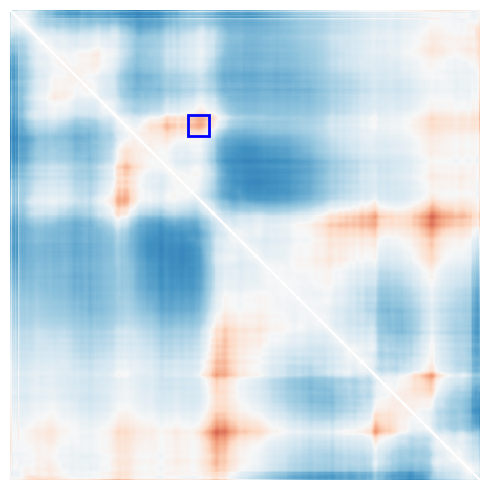

In [63]:
plot_map(before, vmin=-2, vmax=2, palette="RdBu_r", width=5, height=5,highlight_region=highlight_region)

In [39]:
180 * 2048 + 2000

370640

In [41]:
logits = torch.randn(
    1, 4, 4000
)

left_flank = X[:,:, :366640] #.unsqueeze(0)

right_flank = X[:,:, 370640:] #.unsqueeze(0)

In [42]:
left_flank.shape, right_flank.shape

(torch.Size([1, 4, 366640]), torch.Size([1, 4, 677936]))

In [43]:
366640 +  677936 + 4000

1048576

In [44]:
params = boda.generator.StraightThroughParameters(
    data=logits, left_flank=left_flank, right_flank=right_flank, 
    n_samples=1, use_affine=False
)
params.cuda()

StraightThroughParameters(
  (norm): InstanceNorm1d(4, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
)

In [45]:
# energy = boda.generator.MinGapEnergy(model, target_feature=21, target_alpha=-1, a_min=-2., a_max=6.)
# energy = boda.generator.MinGapEnergy(model, target_feature=slice(96,980), target_alpha=-1, a_min=-2., a_max=6.)
energy = boda.generator.MinGapEnergy(model, target_feature=slices, target_alpha=1, a_min=-2., a_max=6.)

#Higher or Lower?:
# - If you want the target feature to be higher in the energy calculation (i.e., the energy should be lower when the target feature is higher), 
# then you’ll use a positive target_alpha.
# - If you want the target feature to be lower (i.e., the energy should be lower when the target feature is lower), 
# then you’ll use a negative target_alpha.

In [46]:
FSP = boda.generator.FastSeqProp(energy, params)

Steps: 100%|██████████| 500/500 [03:41<00:00,  2.26it/s, Loss=855, LR=1e-6]    

(500,)
(500,)
(1,)


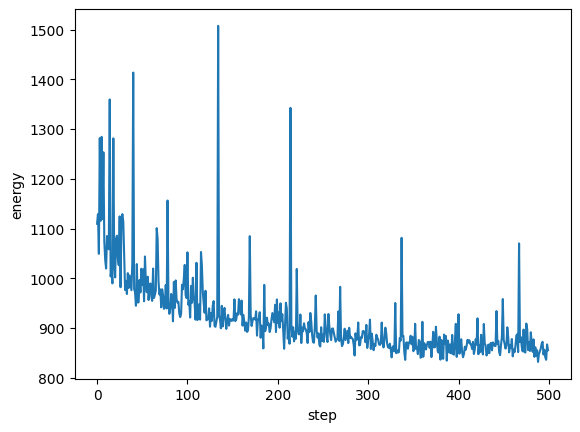

torch.Size([1, 1, 4, 4000])

In [47]:
FSP.run(n_steps=500, lr_scheduler=True, create_plot=True)
proposals = params.get_sample()
proposals.shape

In [48]:
squeezed_proposals = proposals.squeeze(0)

In [49]:
og_seq = X_torch.clone()

In [50]:
og_seq.shape

torch.Size([1, 4, 1048576])

In [51]:
squeezed_proposals.shape

torch.Size([1, 4, 4000])

In [52]:
og_seq[:, :, 366640:370640] = squeezed_proposals

In [53]:
numpy_X_torch = X_torch.cpu().detach().numpy()


In [54]:
squeezed_proposals_np = squeezed_proposals.cpu().detach().numpy()

In [68]:
(numpy_X_torch[:, :, 366640:370640] != squeezed_proposals_np).sum() / 2

2983.0

In [55]:
og_seq.shape

torch.Size([1, 4, 1048576])

In [56]:
with torch.no_grad():
    predictions_new = model(og_seq)

In [57]:
predictions_new.shape

torch.Size([1, 5, 99681])

In [60]:
after = from_upper_triu(predictions_new[:, 0, :], matrix_len=448, num_diags=2)

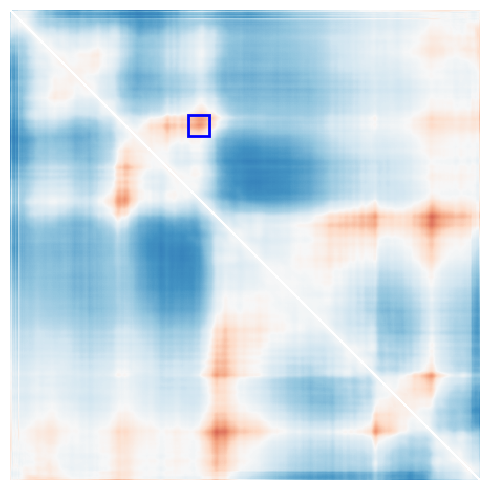

In [64]:
plot_map(after, vmin=-2, vmax=2, palette="RdBu_r", width=5, height=5,highlight_region=highlight_region)

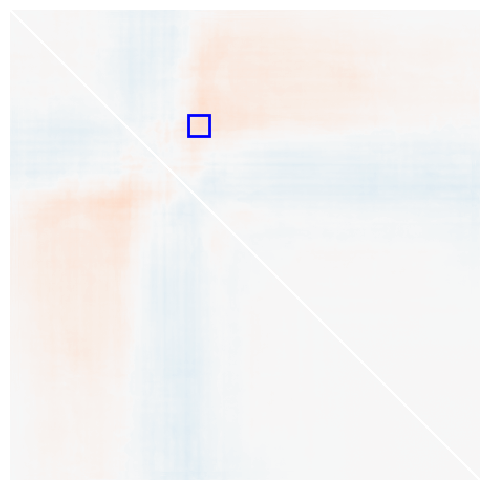

In [66]:
plot_map(after-before, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5,highlight_region=highlight_region)